In [1238]:
import pandas as pd
import torch
from torch . utils . data import TensorDataset , DataLoader
from torch import nn
import numpy as np
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn . model_selection import train_test_split

In [1239]:
df = pd.read_excel("/Users/andrewleacock1/Desktop/ml/ch1/test.xlsx")

df.head()

,Asset ID,Deployed,Quantity Sold,Actual Sales,Actual Total Revenue,Shrink $/Theft,Spoiled Cost,Avg Outs per Visit,Vending Par Level,Visit Count
0,19569,Machine Deployed,0,0.0,0.0,0.0,0.00,35,293,1
1,19571,Machine Deployed,0,0.0,0.0,0.0,0.00,32,159,1
2,A467262,Machine Deployed,113,289.1,289.1,2.5,1.30,21,18,1
3,19570,Machine Deployed,62,151.7,151.7,0.0,0.00,21,186,2
4,19556,Machine Deployed,24,76.0,76.0,0.0,7.77,21,115,2


In [1240]:
df = df.drop(columns=["Asset ID", "Deployed", "Actual Total Revenue", "Actual Sales"]) # Dropping non numerical columns

df["Spoiled Cost"].min(), df["Shrink $/Theft"].min(), df["Avg Outs per Visit"].min(), df["Spoiled Cost"].max(), df["Shrink $/Theft"].max(), df["Avg Outs per Visit"].max()

(np.float64(0.0),
 np.float64(-20230.0),
 np.int64(0),
 np.float64(2368.7),
 np.float64(11036.0),
 np.int64(45))

In [1241]:
# Basis functions

# df["Shrink_exp"] = np.exp(-df["Shrink $/Theft"]/ 10)
df["Spoiled_exp"] = np.exp(-df["Spoiled Cost"]/ 10)
df["Outs_exp"] = np.exp(-df["Avg Outs per Visit"]/ 10)
df["Outs_log"] = np.log(df["Avg Outs per Visit"] / 10 + 1)
df["Outs_inv"] = 1 / (df["Avg Outs per Visit"] + 0.1)

df.head()

,Quantity Sold,Shrink $/Theft,Spoiled Cost,Avg Outs per Visit,Vending Par Level,Visit Count,Spoiled_exp,Outs_exp,Outs_log,Outs_inv
0,0,0.0,0.00,35,293,1,1.000000,0.030197,1.504077,0.028490
1,0,0.0,0.00,32,159,1,1.000000,0.040762,1.435085,0.031153
2,113,2.5,1.30,21,18,1,0.878095,0.122456,1.131402,0.047393
3,62,0.0,0.00,21,186,2,1.000000,0.122456,1.131402,0.047393
4,24,0.0,7.77,21,115,2,0.459783,0.122456,1.131402,0.047393


In [1242]:
y = df["Quantity Sold"].values # Target: Quantuty Sold
X_1 = df.drop(columns=["Quantity Sold", "Outs_exp", "Outs_inv", "Avg Outs per Visit"]).values # Feature Matrix
X = torch.tensor(X_1, dtype=torch.float32) # Turning it into a pytorch tensor making sure the numbers are float32
y = torch.tensor(y, dtype=torch.float32).view(-1,1)


mean = X.mean(dim=0)
std = X.std(dim=0)

X = (X - mean) / std


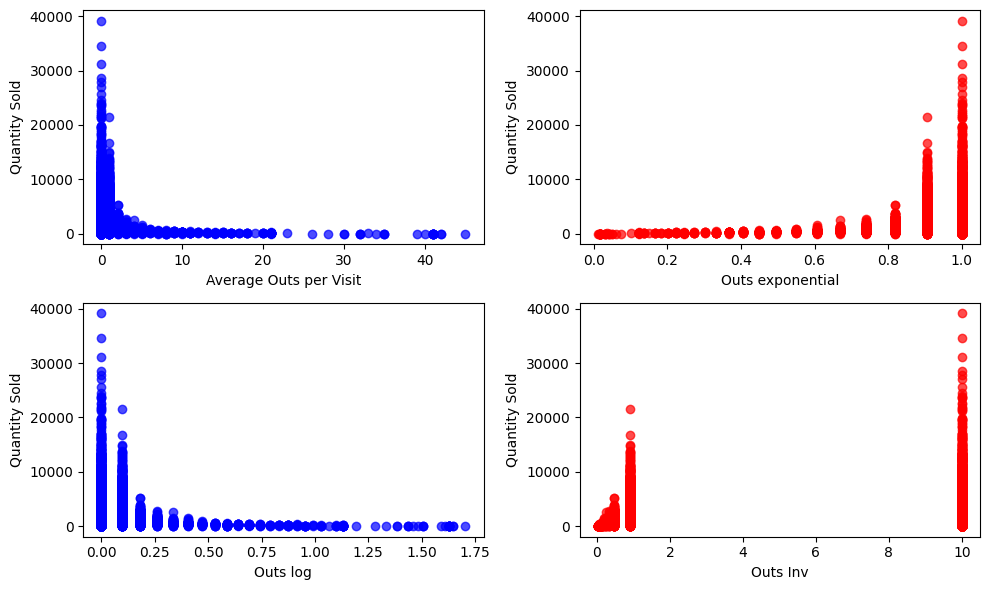

In [1243]:
# 2. Create a figure and a set of subplots (1 row, 2 columns)
# The 'axs' variable will be an array of axes objects (e.g., [ax1, ax2])
fig, axs = plt.subplots(2, 2, figsize=(10, 6)) #

# 3. Plot a scatter plot on the first Axes object
axs[0][0].scatter(x=df["Avg Outs per Visit"], y=y, color='blue', alpha=0.7)
axs[0][0].set_title('')
axs[0][0].set_xlabel('Average Outs per Visit')
axs[0][0].set_ylabel('Quantity Sold')

# 4. Plot a scatter plot on the second Axes object
axs[0][1].scatter(x=df["Outs_exp"],  y=y, color='red', alpha=0.7)
axs[0][1].set_title('')
axs[0][1].set_xlabel('Outs exponential')
axs[0][1].set_ylabel('Quantity Sold')


axs[1][0].scatter(x=df["Outs_log"], y=y, color='blue', alpha=0.7)
axs[1][0].set_title('')
axs[1][0].set_xlabel('Outs log')
axs[1][0].set_ylabel('Quantity Sold')

# 4. Plot a scatter plot on the second Axes object
axs[1][1].scatter(x=df["Outs_inv"],  y=y, color='red', alpha=0.7)
axs[1][1].set_title('')
axs[1][1].set_xlabel('Outs Inv')
axs[1][1].set_ylabel('Quantity Sold')

# 5. Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()

# 6. Display the figure
plt.show()

In [1244]:
X_train , X_test , y_train , y_test = train_test_split (
X , y , test_size =0.2 , random_state =42
)

torch.isnan(X_train).any(),torch.isnan(y_train).any(), torch.isinf(X_train).any(), torch.isnan(X_train).sum()

(tensor(False), tensor(False), tensor(False), tensor(0))

In [1245]:
model = nn.Linear(X_train.shape[1], out_features=1)
X_train

tensor([[-0.1874, -0.1799, -0.5594, -0.4220, -0.7758, -0.0697],
        [-0.1658, -0.3327, -0.8463, -0.4617,  0.2789, -0.0697],
        [ 0.0734, -0.1424, -0.7911,  0.3705, -0.8214, -0.0697],
        ...,
        [ 0.2845, -0.3267,  0.6106,  1.0046,  0.1741, -0.0697],
        [-0.1319, -0.3509,  1.1846, -0.3428,  0.6663,  0.5241],
        [ 0.1924, -0.2372,  2.8844,  2.5105, -0.6243, -0.7202]])

In [1246]:
model.weight, model.bias

(Parameter containing:
 tensor([[ 0.0855, -0.0777,  0.1391, -0.2282, -0.0756, -0.3543]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.1577], requires_grad=True))

In [1247]:
loss_fn = nn.MSELoss()



In [1248]:
optimizer = optim.SGD(model.parameters(), lr=0.0005)


In [1249]:
predictions = model(X_train)
predictions

tensor([[-0.0579],
        [-0.1548],
        [-0.2481],
        ...,
        [-0.2407],
        [-0.1348],
        [ 0.0080]], grad_fn=<AddmmBackward0>)

In [1250]:
loss = loss_fn(predictions, y_train)

loss

tensor(16541393., grad_fn=<MseLossBackward0>)

In [1251]:
epochs = 10000
loss_array = []
for epoch in range(epochs):
    predictions = model(X_train)
    loss = loss_fn(predictions, y_train)
    loss_array.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
if epoch % 100 == 0:
    print(epoch, loss.item())

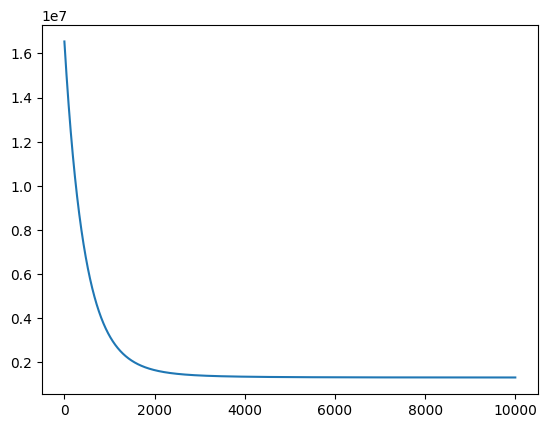

In [1252]:
plt.plot(range(epochs), loss_array)
plt.show()

In [1253]:
model.weight, model.bias

(Parameter containing:
 tensor([[  86.5730, -546.8310,  843.9489, 2177.1792,  173.2175,  -75.4370]],
        requires_grad=True),
 Parameter containing:
 tensor([2987.3950], requires_grad=True))

In [1254]:
new_predictions = model(X_train)
new_predictions

tensor([[ 1549.4966],
        [ 1489.1453],
        [ 3073.6230],
        ...,
        [ 5928.5996],
        [ 3497.1494],
        [10979.9404]], grad_fn=<AddmmBackward0>)

In [1255]:
with torch . no_grad () :
    test_pred = model ( X_test )
    test_loss = loss_fn ( test_pred , y_test )
print ( " Test Loss : " , test_loss.item() )

 Test Loss :  1594678.25


In [1256]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, test_pred.detach().numpy())
print(f"R2: {r2}")

R2: 0.7910295724868774


In [1257]:
weights = model.weight.detach().numpy().flatten()
features = df.drop(columns=["Quantity Sold", "Outs_exp", "Outs_inv", "Avg Outs per Visit"]).columns

pairs = list(zip(features, weights))
pairs.sort(key=lambda x: abs(x[1]), reverse=True)

for name, w in pairs:
    print(f"{name}: {w:.4f}")

Visit Count: 2177.1792
Vending Par Level: 843.9489
Spoiled Cost: -546.8310
Spoiled_exp: 173.2175
Shrink $/Theft: 86.5730
Outs_log: -75.4370


In [1266]:
with torch.no_grad():
    preds = model(X_test)

for i in range(len(preds)):
    print(f"Pred: {preds[i].item():.2f} | Actual: {y_test[i].item():.2f}")

Pred: 2611.56 | Actual: 2759.00
Pred: 1642.07 | Actual: 1391.00
Pred: 4483.77 | Actual: 4112.00
Pred: 4182.68 | Actual: 3187.00
Pred: 2474.35 | Actual: 2854.00
Pred: 1486.37 | Actual: 1562.00
Pred: 6704.38 | Actual: 7769.00
Pred: 8547.78 | Actual: 6398.00
Pred: -561.59 | Actual: 0.00
Pred: 3591.69 | Actual: 3070.00
Pred: 4275.86 | Actual: 5836.00
Pred: 3692.91 | Actual: 3536.00
Pred: 3213.99 | Actual: 1950.00
Pred: 3401.68 | Actual: 1808.00
Pred: 1310.57 | Actual: 1609.00
Pred: 911.12 | Actual: 771.00
Pred: 2077.02 | Actual: 2009.00
Pred: 3009.10 | Actual: 3183.00
Pred: 4378.18 | Actual: 5455.00
Pred: 488.72 | Actual: 598.00
Pred: 3074.96 | Actual: 3389.00
Pred: 5992.11 | Actual: 4990.00
Pred: 858.80 | Actual: 118.00
Pred: -191.84 | Actual: 497.00
Pred: 4733.11 | Actual: 5040.00
Pred: 5765.03 | Actual: 5826.00
Pred: 3358.71 | Actual: 2660.00
Pred: 55.40 | Actual: 322.00
Pred: 2566.70 | Actual: 2089.00
Pred: -1182.26 | Actual: 80.00
Pred: 803.28 | Actual: 1632.00
Pred: 3800.61 | Actual:

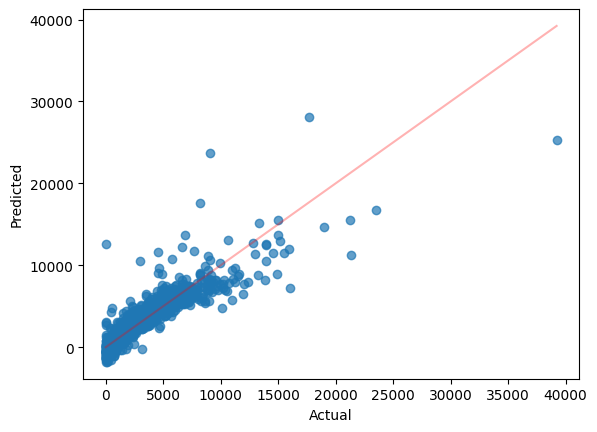

In [1270]:
import matplotlib.pyplot as plt

with torch.no_grad():
    preds = model(X_test)

preds = preds.detach().numpy().flatten()
actual = y_test.detach().numpy().flatten()

plt.scatter(actual, preds, alpha=0.7)

# perfect prediction line
plt.plot([actual.min(), actual.max()],
         [actual.min(), actual.max()],
         color="red", alpha=0.3)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()